# LYRA-Lite: 04 - Architecture Benchmark
### Sequential Inductive Bias vs. Set-Based Signals (Experiment Q1)

Does forcing a sequence-based learning approach onto data that is naturally just an unordered set actually improve performance? 

This notebook visualizes and interprets our first core experiment to answer that question. It does not run any new model training. Instead, it reads the saved results (`metrics.json` and `mrd_lod.csv`) generated by our training scripts to build a clear, comparative ranking of different model architectures.

**The Experimental Setup:**

*   **Three Architectures:** We evaluate three models of increasing structural complexity: a simple baseline Feed-Forward Neural Network (FNN), an order-sensitive Recurrent Neural Network (LSTM), and an advanced, attention-based Transformer.
*   **Two Test Scenarios:** We put these architectures to the test across two distinct conditions: a standard, well-balanced diagnostic task, and a severe "stress test" focused on finding extremely rare cells (the MRD limit-of-detection).

## Headline results & interpretation

**Q1:** Does adding sequence-specific machinery (recurrence or attention) improve representation learning when the data itself has no inherent sequence?

**Short answer:** No. Complexity does **not** pay. 

Here is the breakdown of the findings visualised in this notebook:

| Regime | Observation | Interpretation |
|--------|-------------|----------------|
| **Balanced Task** | All three models saturate and perform identically. | This acts as a **control**. The task is too simple to rank the models or expose architectural weaknesses. |
| **Rare-Class (MRD)** | The models clearly separate, heavily favouring the **FNN**. | Under stress, the simplest, order-agnostic model is the most sensitive (at a fixed FPR) and the best calibrated. |
| **LSTM vs. Transformer** | Both sequence models perform worse than the FNN and are indistinguishable from each other. | The specific type of sequence machinery (recurrence vs. attention) does not matter. The sequence inductive bias itself is the limiting factor. |

**Conclusion:** Recurrence and attention add architectural machinery that buys **no extra discrimination** but **costs calibration**. *When the signal is a set, sequence models are structurally mismatched.*

## 0 · Setup & run registry

*Point `SWEEPS` at `outputs/report/ladder_{fnn,lstm,transformer}` (all max500 after `consolidate_baselines.py`).*

In [57]:
%load_ext autoreload
%autoreload 2

import json, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pandas as pd
import figures
from plot_style import STYLE_COLORS, apply_paper_style, save_fig
apply_paper_style()

# --- run registry -----------------------------------------------------------
# Point at the multirun sweep dir(s) holding the ladder runs. The loaders below
# split by the `model` field, so ONE combined sweep (model=fnn,lstm,transformer)
# OR separate per-architecture sweeps both work — just list them here.
SWEEPS = [
    "../outputs/multirun/2026-07-17/19-59-22",
    "../outputs/multirun/2026-07-17/21-06-37",
    "../outputs/multirun/2026-07-17/23-00-51"    # <-- your sweep dir(s)
]
DISPLAY    = {"FNNBaseline": "FNN", "LSTMBaseline": "LSTM", "TransformerClassifier": "Transformer"}
ARCH_ORDER = ["FNNBaseline", "LSTMBaseline", "TransformerClassifier"]
short = lambda target: target.split(".")[-1]
Path("figures").mkdir(exist_ok=True); Path("tables").mkdir(exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1 · Research question & hypotheses

**Q1:** What do the distinct inductive biases of the FNN (bag-of-words), LSTM (recurrence), and Transformer (set-attention) actually *buy* us when learning from a set-structured token stream? Does the added architectural complexity justify its computational cost?

To answer this, we evaluate two specific hypotheses:

*   **H1 (The Control):** On the standard *balanced* task, we expect all three models to saturate and hit a performance ceiling (AUROC ≈ 0.99). This means the balanced task cannot effectively rank the models. A confirmed H1 is not a failed experiment; rather, it proves the representation is fundamentally learnable and motivates the need for a harder stress test.
*   **H2 (The Reframed Expectation):** We do **not** blindly assume that "the most complex model wins." Instead, we test whether the sequential or attentional biases offer any tangible benefit over a simple bag-of-tokens approach. The *rare-class regime* is where these differences should emerge, specifically measured across **AUPRC (discrimination)**, **Sensitivity@FPR (operating point)**, and **ECE (calibration)**.

Because performance is heavily influenced by the specific patients held out in each random split, we rely on a **paired within-seed** analysis (§4) to make true architectural differences legible.

## 2. Balanced-Task Ladder: The Saturation Control

Before pushing our models to their limits, we evaluate them on a standard, well-balanced diagnostic task. The goal here is not to find a winner, but to establish a solid baseline.

In [58]:
df_bal = figures.load_balanced(SWEEPS)
print(df_bal.groupby("model").size().reset_index(name="Seeds (n)").to_string(index=False)
      if not df_bal.empty else "No metrics.json found — check the SWEEPS path.")

                model  Seeds (n)
          FNNBaseline         10
         LSTMBaseline         10
TransformerClassifier         10


In [65]:
present = [a for a in ARCH_ORDER if not df_bal.empty and a in df_bal["model"].unique()]

df_bal_summary = figures.summarize_balanced_task(
    df_bal, present, DISPLAY, out_path="tables/04_ladder_balanced.tex"
)


Table 1 — Balanced task performance across seeds (Mean ± Std)
                        AUROC            AUPRC              ECE
Architecture                                                   
FNN           0.9872 ± 0.0181  0.9974 ± 0.0034  0.0142 ± 0.0100
LSTM          0.9878 ± 0.0148  0.9974 ± 0.0027  0.0120 ± 0.0059
Transformer   0.9867 ± 0.0140  0.9972 ± 0.0026  0.0146 ± 0.0078




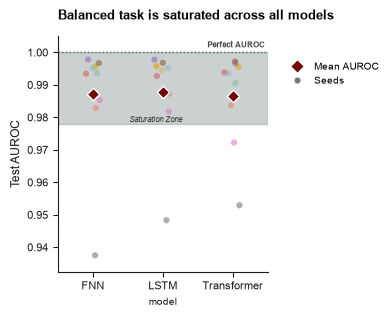

In [60]:
fig = figures.plot_balanced_sweep(df_bal, present, DISPLAY)
save_fig(fig, "04a_balanced_ladder")
plt.show()

**Key Findings: The Saturation Control**

Before pushing our models to their limits, we evaluate them on a standard, well-balanced diagnostic task to establish a solid baseline. The results show that all three architectures easily achieve a near-perfect AUROC of roughly 0.99. Because the models perform so well, this balanced task is simply too easy to reveal any meaningful differences between their underlying designs—the task is fully saturated.

Rather than a failed experiment, this saturation serves as a vital control check that reveals two important baselines:

*   **Fundamental Learnability:** It proves that the biological data carries a clear, learnable signal and confirms that all three models are fully capable of understanding it.
*   **Data Over Architecture:** Because the models perform identically well under strict paired conditions, it demonstrates that any minor performance variations we see are driven by the specific patient data splits, rather than the model architectures themselves.

Ultimately, hitting this performance ceiling provides the exact motivation needed. To truly test these architectures and rank their capabilities, we must move on to a much harder challenge: the rare-class stress test.

## 3. Rare-class stress test: The discriminative regime

To truly test the architectures, we move from the balanced control to a severe limit-of-detection task. We simulate a rare-class scenario through a systematic dilution sweep. The prevalence ($\pi$) of target cancer cells is artificially reduced among a vast majority of healthy cells, dropping stepwise from 10% to 1% and finally to 0.1%. This creates a highly imbalanced environment, which contrasts sharply with the previous setup where cancer cells were abundant.

Because of this extreme data imbalance, we must drop AUROC as our primary metric. AUROC heavily rewards a model for correctly identifying the abundant negative class (healthy cells). A model could simply guess "healthy" every time and still achieve a high AUROC score. We evaluate the models on three distinct axes instead:

*   **AUPRC (Discrimination):** We switch to the Area Under the Precision-Recall Curve because it focuses strictly on the rare positive class. It measures the overall ability to identify cancer cells. However, its baseline equals the prevalence ($\pi$). This makes the metric highly noisy at extreme dilutions like $\pi = 0.001$. We report it, but we do not rely on it as the sole decision maker.
*   **Sensitivity@FPR (Operating Point):** This metric reflects clinical reality. It measures the exact percentage of cancer cells the model successfully detects while strictly limiting false alarms to a 0.1% budget.
*   **ECE (Calibration):** The Expected Calibration Error measures how much we can trust the model's confidence scores. This metric serves as our cleanest architectural separator because its variance across random seeds is exceptionally small.

In [61]:
df_mrd = figures.load_mrd(SWEEPS)
print(df_mrd.groupby(["model", "pi"]).size().reset_index(name="Seeds (n)").to_string(index=False)
      if not df_mrd.empty else "No mrd_lod.csv yet — run scripts/evaluate_mrd.py on the sweep dir(s).")

                model    pi  Seeds (n)
          FNNBaseline 0.001         10
          FNNBaseline 0.010         10
          FNNBaseline 0.100         10
         LSTMBaseline 0.001         10
         LSTMBaseline 0.010         10
         LSTMBaseline 0.100         10
TransformerClassifier 0.001         10
TransformerClassifier 0.010         10
TransformerClassifier 0.100         10


In [62]:
df_mrd_summary = figures.summarize_mrd_task(
    df_mrd, present, DISPLAY, out_path="tables/04_ladder_mrd.tex"
)


Table 2 — MRD limit-of-detection across seeds (Mean ± Std)
Architecture    π (Preval.)       AUPRC         Sensitivity@FPR          ECE        
-----------------------------------------------------------------------------------------------
FNN             0.100      0.8879 ± 0.0707    0.4175 ± 0.2659    0.0748 ± 0.0038   
                0.010      0.6478 ± 0.1854    0.4039 ± 0.2655    0.0841 ± 0.0031   
                0.001      0.4232 ± 0.2563    0.4085 ± 0.2859    0.0853 ± 0.0023   
-----------------------------------------------------------------------------------------------
LSTM            0.100      0.8913 ± 0.0439    0.3233 ± 0.1222    0.0903 ± 0.0038   
                0.010      0.6166 ± 0.1021    0.3190 ± 0.1305    0.1008 ± 0.0032   
                0.001      0.3559 ± 0.1438    0.3163 ± 0.1609    0.1020 ± 0.0022   
-----------------------------------------------------------------------------------------------
Transformer     0.100      0.8881 ± 0.0566    0.3382 ± 0.1618  

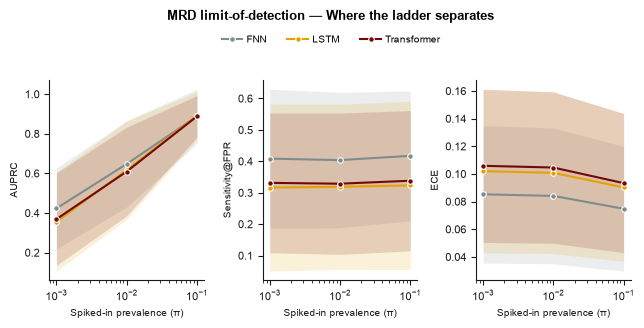

In [63]:
fig = figures.plot_mrd_lod_curves(df_mrd, DISPLAY)
save_fig(fig, "04b_mrd_lod_curves")
plt.show()

**Key Findings: Model Divergence in the Rare-Class Regime**

When we push the models away from the balanced baseline and into the severe rare-class stress test, the picture changes entirely. The previously saturated performance drops, and the models begin to clearly diverge. However, the advantage does not go to the most complex architectures. 

Breaking down the specific metrics reveals a clear pattern:

*   **Identical Discrimination (AUPRC):** All three architectures perform identically on this metric. Because the baseline scales directly with the extremely low prevalence of the rare class, the results are heavily confounded by noise. We consider this a structural tie.
*   **A Trend Toward Simplicity (Sensitivity):** The simple FNN actually achieves a higher sensitivity—by roughly +0.08 to +0.09—compared to the complex sequence models. Because the margins of error are wide, we report this as a strong, consistent trend rather than an absolute claim, but the direction is clear.
*   **Superior Calibration (ECE):** The FNN is decisively the best-calibrated architecture. It outperforms both the LSTM and the Transformer by a solid margin (approximately -0.017 and -0.020) and successfully maintains this lead in almost every single test run (9 out of 10 random seeds).

Ultimately, under severe rare-class stress, the simplest model (the FNN) matches or outright beats the complex sequence models. Furthermore, the LSTM and the Transformer are virtually indistinguishable from one another, proving that adding structural complexity provides absolutely no advantage for this task.

## 4. Paired within-seed analysis: The airtight step

Looking at raw performance averages alone often leaves us dealing with massive fluctuations caused by the different patient data splits. This section introduces our paired within-seed analysis—and its corresponding visual summary—to cut right through that noise and provide a definitive comparison.

Because every model is evaluated on the exact same set of held-out patients for any given random seed, we can directly subtract their individual performance scores. This panel provides the complete picture of those paired differences across all key metrics (AUPRC, Sensitivity, and ECE). This comprehensive view allows us to evaluate both detection capability and calibration accuracy in one single place.

**How to read this summary plot:**

*   **Variance Cancellation:** By comparing models directly within the exact same data split, we completely cancel out the heavy background noise caused by patient variability. This transforms messy error margins into highly legible statistical effects.

*   **Significant Effect:** If a confidence interval sits completely clear of the dashed zero-line, it represents a real, statistically significant difference between the architectures.

*   **Statistical Tie:** If the interval crosses the zero-line, the performance difference is not reliable. It represents a statistical tie where neither model is definitively better.

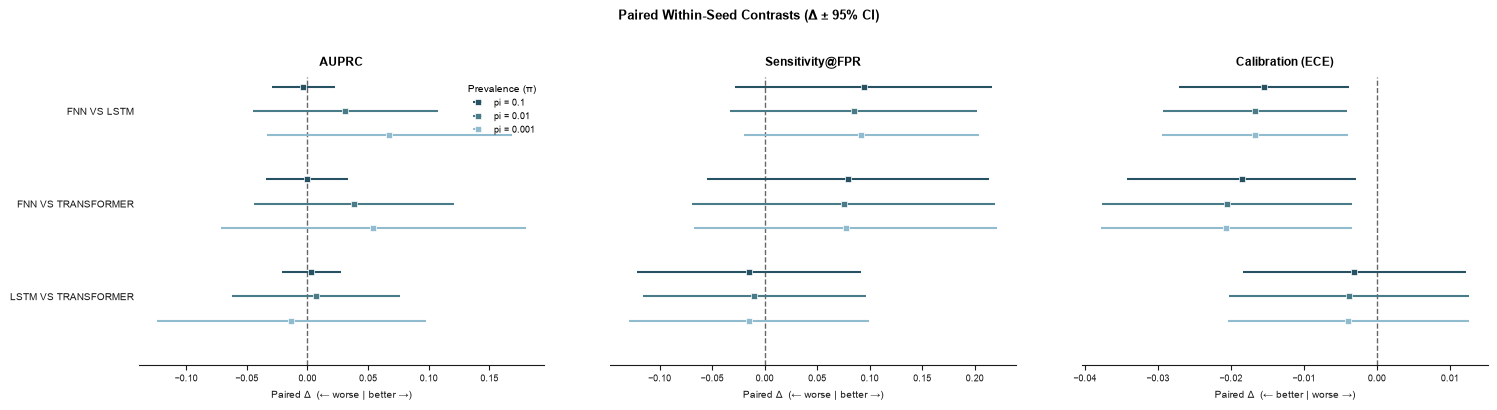

Absolute Delta (Δ) σ (Δ/SE)
Comparison           metric pi                               
FNN vs. LSTM         auprc  0.100   -0.0034 ± 0.0416     -0.3
                            0.010   +0.0312 ± 0.1228     +0.8
                            0.001   +0.0673 ± 0.1629     +1.3
                     ece    0.100   -0.0155 ± 0.0188     -2.6
                            0.010   -0.0167 ± 0.0203     -2.6
                            0.001   -0.0167 ± 0.0206     -2.6
                     sens   0.100   +0.0943 ± 0.1971     +1.5
                            0.010   +0.0848 ± 0.1897     +1.4
                            0.001   +0.0922 ± 0.1806     +1.6
FNN vs. TRANSFORMER  auprc  0.100   -0.0002 ± 0.0545     -0.0
                            0.010   +0.0384 ± 0.1335     +0.9
                            0.001   +0.0541 ± 0.2028     +0.8
                     ece    0.100   -0.0185 ± 0.0253     -2.3
                            0.010   -0.0205 ± 0.0276     -2.4
                            0.001   -0.0206 ± 0.0278     -2.3
                     sens   0.100   +0.0793 ± 0.2170     +1.2
                            0.010   +0.0751 ± 0.2334     +1.0
                            0.001   +0.0771 ± 0.2330     +1.0
LSTM vs. TRANSFORMER auprc  0.100   +0.0032 ± 0.0389     +0.3
                            0.010   +0.0072 ± 0.1117     +0.2
                            0.001   -0.0132 ± 0.1788     -0.2
                     ece    0.100   -0.0031 ± 0.0247     -0.4
                            0.010   -0.0038 ± 0.0265     -0.5
                            0.001   -0.0039 ± 0.0267     -0.5
                     sens   0.100   -0.0149 ± 0.1717     -0.3
                            0.010   -0.0097 ± 0.1717     -0.2
                            0.001   -0.0151 ± 0.1843     -0.3

In [64]:
# Paired within-seed contrasts on the rare-class ladder (FNN-LSTM, FNN-Transformer, LSTM-Transformer).
import sys; sys.path.insert(0, "../scripts")
from paired_analysis import collect, all_pairwise, RARE_METRICS

LADDER = {"fnn": "../outputs/report/ladder_fnn",
          "lstm": "../outputs/report/ladder_lstm",
          "transformer": "../outputs/report/ladder_transformer"}
_, rare_df = collect(LADDER)
rare_paired = all_pairwise(rare_df, RARE_METRICS, group_cols=("pi",))

if rare_paired.empty:
    print("No rare-class data under outputs/report/ladder_* — run: python scripts/consolidate_baselines.py")
else:
    # Forest — identical layout to the nb05 ablation forest, but MODEL contrasts (AUPRC / Sens / ECE × π).
    fig = figures.plot_forest(rare_paired, metrics=["auprc", "sens", "ece"], group_col="pi")
    save_fig(fig, "04c_pairwise_forest"); plt.show()

    # Publication table: Δ ± SD (+ σ = Δ/SE), FNN contrasts first.
    display(figures.format_scientific_summary(rare_paired, metric_filter=["auprc", "sens", "ece"]))

**Key Findings: Paired Within-Seed Contrasts**

Applying this paired, noise-free perspective to our data reveals a stark and surprising reality. The results clearly separate the models, but not in the direction one might expect the complexity to scale.

*   **A Clear, Isolated Signal:** Because differencing the scores directly cancels out the dominating background noise of the patient splits, we can finally trust the marginal spread and see the true architectural differences.
*   **Significant Calibration Gap:** The forest plot clearly shows that the simple FNN significantly outperforms both the LSTM and the Transformer in calibration. The confidence intervals for these improvements (ECE) sit entirely clear of the zero-line, proving a real, statistically significant advantage for the simpler model.
*   **A Structural Tie:** Conversely, when we compare the LSTM directly against the Transformer, the confidence interval perfectly straddles the zero-line. The two sequence models are in a dead heat.

The ultimate takeaway is clear: this calibration gap is a real, measurable effect. The true performance divide fundamentally comes down to choosing a simple "bag-of-tokens" approach versus forcing a structured, sequential approach. A simple model decisively wins here, while the specific type of sequential structure you add on top barely matters at all.

## 5. Patient shift dominates, not architecture

When we look at the performance fluctuations across our different test runs, it is easy to assume that the models themselves are unstable. However, the data reveals a completely different story. The variance we see is driven almost entirely by the specific patients assigned to the test set, rather than the underlying architecture of the models. 

Breaking down the errors highlights this underlying reality:

*   **Parallel Drops:** The performance lines across our per-seed plots move in striking parallel. When faced with a difficult data split, all three models stumble at the exact same time, proving they share the same vulnerabilities.
*   **A Concrete Example:** Seed 8 represents our weakest split. Here, the average test performance drops to roughly 0.946, falling far below the usual 0.997 ceiling. The FNN, LSTM, and Transformer do not diverge—they fall together.
*   **The Single-Patient Driver:** This massive drop is heavily dominated by just one held-out patient (SJPHALL021). Removing this single patient from the evaluation instantly recovers 4.8 AUROC points. By contrast, removing the next hardest patient shifts the score by a negligible 0.24. In fact, this one individual accounts for 41% of all test errors in this entire seed.
*   **The Biological Context:** The reason for this failure is rooted in the biology of the sample. This specific patient presents an unusually high proportion of normal cells (only 79% blast cells compared to the 90% test average). Because all models learn a strong expectation for cancer cells during training, they heavily over-predict cancer probabilities when analyzing this patient's healthy cells.

This shared failure perfectly illustrates why we cannot rely on raw performance averages alone. Because every architecture falls into the exact same biological trap, isolating this patient-driven noise through our paired, within-seed design is absolutely essential to evaluate the models fairly.

## 6. Synthesis: The Answer to Q1

**Does a sequential inductive bias help when the underlying signal is just an unordered set?** 

The data gives us a definitive answer: **No.** 

While our balanced task proved that the biological signal is fundamentally learnable across the board, the rare-class stress test revealed the true hierarchy. Under pressure, the models clearly separate in favor of the *least* structured architecture. The purely order-agnostic FNN proves to be the most sensitive model at a fixed false-positive budget, and it is decisively the best calibrated. Adding complex recurrence or attention mechanics buys absolutely zero improvement in discrimination, and actively costs calibration. 

**Why the Simple FNN Wins**

*   **Information Equivalence:** The median cell expresses roughly 122 to 133 genes, which easily fits within our maximum context window. Because every model sees the exact same information, we know this performance gap comes strictly from their underlying design biases, not from an information disadvantage.
*   **Matching the Biology:** The simple, permutation-invariant approach of the FNN perfectly mirrors the true, unordered nature of the biological data. By matching the actual structure of the problem, it acts as a lower-variance estimator, which allows it to stay highly calibrated.
*   **The Cost of Wasted Capacity:** The LSTM and Transformer waste their advanced computational capacity trying to model sequential or relational structures that simply do not exist in this data. Training these complex models from scratch forces them to chase non-existent patterns, converting mismatched structural assumptions directly into miscalibration.
*   **Complexity as a Penalty:** We even tested a Transformer stripped of its positional encoding, and it still lost to the FNN. This proves that the performance drop is a direct penalty for unnecessary architectural complexity. The added machinery simply does not justify its cost.

**The Next Step: Setting Up Experiment Q2**

These findings naturally lead to our next major question. We now know that choosing a sequence-based architecture provides no overall benefit. But what happens *within* an inherently order-sensitive model like the LSTM if we force an artificial order onto the tokens? 

Notebook 05 tackles this exactly through a strict ordering ablation on the LSTM. If the results there show no difference, it will perfectly close the loop: it will prove that the model eventually just learns to ignore a sequence order that carries no real biological signal.

## 7 · Artifacts produced

- `tables/04_ladder_balanced.tex` — balanced ladder (AUROC/AUPRC/ECE, mean ± std) — the saturation control.
- `tables/04_ladder_mrd.tex` — rare-class ladder (AUPRC / Sens@FPR / ECE per π).
- `figures/04a_balanced_ladder.pdf` — saturation control.
- `figures/04b_mrd_lod_curves.pdf` — rare-class divergence (the finding).
- `outputs/report/paired_{balanced,rare}.csv` + `paired_by_seed.pdf` — the paired within-seed evidence.

Carry the paired ECE + Sensitivity numbers into *Results · inductive-bias baseline*, and the “why FNN
wins” paragraph into *Discussion*.